<a href="https://colab.research.google.com/github/alhmsiSWE/form-coach/blob/main/04_evaluation_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Form Coach - Notebook 04: Evaluation & Export

**Deliverable 3: Model Evaluation (25 pts)** and **Deliverable 5: Deployment & Export (5 pts)**

A real `model.val()` run on the fine-tuned exercise detector, with mAP50, mAP50-95,
precision/recall and a confusion matrix, interpreted for this use case: where the model
produces false positives versus false negatives, and how the confidence threshold was
chosen from that cost asymmetry.

The trained model is then exported to ONNX.

**Run all cells top to bottom, then File -> Download -> Download .ipynb with output intact.**

## 0. Setup

In [1]:
!pip install -q ultralytics roboflow lap onnx onnxruntime onnxslim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 7.6 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
import ultralytics

ultralytics.checks()

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


## 1. Dataset

The same Roboflow Universe dataset used for training in notebook 03. Evaluation must run
on the identical `data.yaml` so the validation split is the one the model never trained on.

In [3]:
from getpass import getpass
os.environ["ROBOFLOW_API_KEY"] = getpass("Roboflow API key: ")

Roboflow API key: ··········


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
project = rf.workspace("student-t7wnl").project("exercise-rep-identifier")
version = project.version(2)
dataset = version.download("yolov8")

DATA_YAML = f"{dataset.location}/data.yaml"
print(f"\ndata.yaml : {DATA_YAML}")
print(open(DATA_YAML).read())

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to exercise-rep-identifier-2 in yolov8:: 100%|██████████| 422/422 [00:00<00:00, 6940.21it/s]


data.yaml : /content/exercise-rep-identifier-2/data.yaml
names:
- head
nc: 1
roboflow:
  license: MIT
  project: exercise-rep-identifier
  url: https://universe.roboflow.com/student-t7wnl/exercise-rep-identifier/dataset/2
  version: 2
  workspace: student-t7wnl
test: ../test/images
train: ../train/images
val: ../valid/images



## 2. The model under evaluation

Notebook 03 produced two runs; run 1 (baseline) scored higher on validation mAP50-95
(0.375 vs 0.325) and is the model evaluated here.

Weights are not committed to git, so if this runtime does not already have them the
baseline run is reproduced here. `results.save_dir` is read from the returned object
rather than hardcoding a path - Ultralytics writes to `runs/detect/<project>/<name>/`,
not `<project>/<name>/`.

In [5]:
BEST_WEIGHTS = None

# If notebook 03 ran in this same runtime, reuse its weights.
for root, dirs, files in os.walk("/content"):
    if root.endswith("run1_baseline/weights") and "best.pt" in files:
        BEST_WEIGHTS = os.path.join(root, "best.pt")
        break

if BEST_WEIGHTS is None:
    print("No existing weights found - reproducing the baseline run (about 2 minutes).\n")
    trainer = YOLO("yolo26n.pt")
    results = trainer.train(
        data=DATA_YAML,
        epochs=25,
        imgsz=640,
        batch=16,
        patience=10,
        project="runs_formcoach",
        name="run1_baseline",
        exist_ok=True,
        verbose=False,
    )
    BEST_WEIGHTS = os.path.join(str(results.save_dir), "weights", "best.pt")

print(f"Evaluating: {BEST_WEIGHTS}")
assert os.path.exists(BEST_WEIGHTS), "Weights missing"

os.makedirs("weights", exist_ok=True)
import shutil
shutil.copy(BEST_WEIGHTS, "weights/best.pt")
print("Copied to weights/best.pt")

No existing weights found - reproducing the baseline run (about 2 minutes).

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/exercise-rep-identifier-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yol

## 3. Validation run

`model.val()` on the validation split - 38 images the model never saw during training.

In [6]:
model = YOLO(BEST_WEIGHTS)

metrics = model.val(
    data=DATA_YAML,
    split="val",
    plots=True,
    project="eval_formcoach",
    name="val_run",
    exist_ok=True,
)

VAL_DIR = str(metrics.save_dir)

mAP50    = float(metrics.box.map50)
mAP5095  = float(metrics.box.map)
precision = float(metrics.box.mp)
recall    = float(metrics.box.mr)

summary = pd.DataFrame([{
    "mAP50": round(mAP50, 4),
    "mAP50-95": round(mAP5095, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
}])

print("\nValidation metrics")
print(summary.to_string(index=False))
summary.to_csv("04_val_metrics.csv", index=False)
print(f"\nArtifacts written to: {VAL_DIR}")

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1699.6±417.1 MB/s, size: 49.9 KB)
val: Scanning /content/exercise-rep-identifier-2/valid/labels.cache... 38 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 38/38 14.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.6it/s 1.2s
                   all         38         93      0.619      0.527      0.585      0.375
Speed: 3.6ms preprocess, 11.6ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/eval_formcoach/val_run

Validation metrics
 mAP50  mAP50-95  precision  recall
0.5848    0.3752     0.6191  0.5269

Artifacts written to: /content/runs/detect/eval_formcoach/val_run


### What these numbers mean

- **mAP50** - how well boxes are found when a loose overlap (IoU 0.5) counts as correct.
  This is the "did it find the thing at all" number.
- **mAP50-95** - the same averaged over IoU 0.5 to 0.95, so it also penalises boxes that
  are in roughly the right place but badly sized. It is always lower, and the gap between
  the two is a localisation-quality signal rather than a detection-failure signal.
- **Precision** - of everything the model flagged, how much was real. Low precision means
  false positives.
- **Recall** - of everything that was really there, how much the model found. Low recall
  means false negatives.

In [7]:
gap = mAP50 - mAP5095
print(f"mAP50 - mAP50-95 gap : {gap:.3f}")
if gap > 0.3:
    print("-> Large gap: the model finds the object but its boxes are loosely placed.")
else:
    print("-> Moderate gap: localisation is roughly in line with detection ability.")

if precision > recall:
    print(f"-> Precision ({precision:.3f}) exceeds recall ({recall:.3f}): the model is")
    print("   conservative - it misses more than it invents. Errors lean to false negatives.")
else:
    print(f"-> Recall ({recall:.3f}) exceeds precision ({precision:.3f}): the model is")
    print("   permissive - it flags more than exists. Errors lean to false positives.")

mAP50 - mAP50-95 gap : 0.210
-> Moderate gap: localisation is roughly in line with detection ability.
-> Precision (0.619) exceeds recall (0.527): the model is
   conservative - it misses more than it invents. Errors lean to false negatives.


## 4. Overfitting check

Lab 4B assigns the same value to both `train_map` and `val_map`, so its comparison is a
number against itself and always reports no overfitting. The real check evaluates the two
splits separately with `split=`.

In [8]:
m = YOLO(BEST_WEIGHTS)
train_metrics = m.val(data=DATA_YAML, split="train", verbose=False)
val_metrics   = m.val(data=DATA_YAML, split="val",   verbose=False)

train_map50 = float(train_metrics.box.map50)
val_map50   = float(val_metrics.box.map50)
of_gap      = train_map50 - val_map50

print(f"train mAP50 : {train_map50:.4f}")
print(f"val   mAP50 : {val_map50:.4f}")
print(f"gap         : {of_gap:+.4f}")

if of_gap > 0.15:
    verdict = "Large gap - the model memorised training images rather than learning the object."
elif of_gap > 0.05:
    verdict = "Moderate gap - mild overfitting, expected on a dataset this small."
else:
    verdict = "Small gap - the model generalises to unseen images."
print(f"-> {verdict}")

pd.DataFrame([{"train_mAP50": round(train_map50, 4),
               "val_mAP50": round(val_map50, 4),
               "gap": round(of_gap, 4),
               "verdict": verdict}]).to_csv("04_overfitting_check.csv", index=False)

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1608.9±492.0 MB/s, size: 42.4 KB)
train: Scanning /content/exercise-rep-identifier-2/train/labels.cache... 145 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 145/145 55.3Mit/s 0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.2it/s 3.1s
                   all        145        307        0.6      0.524      0.591      0.366
Speed: 3.6ms preprocess, 6.0ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8.4.130 🚀 Python-3.13.15 torc

## 5. Confusion matrix

`val(plots=True)` writes the confusion matrix into the run directory. It shows how
detections were distributed between the real class and background - the background column
is false negatives (missed objects), the background row is false positives (invented ones).

confusion_matrix_normalized.png


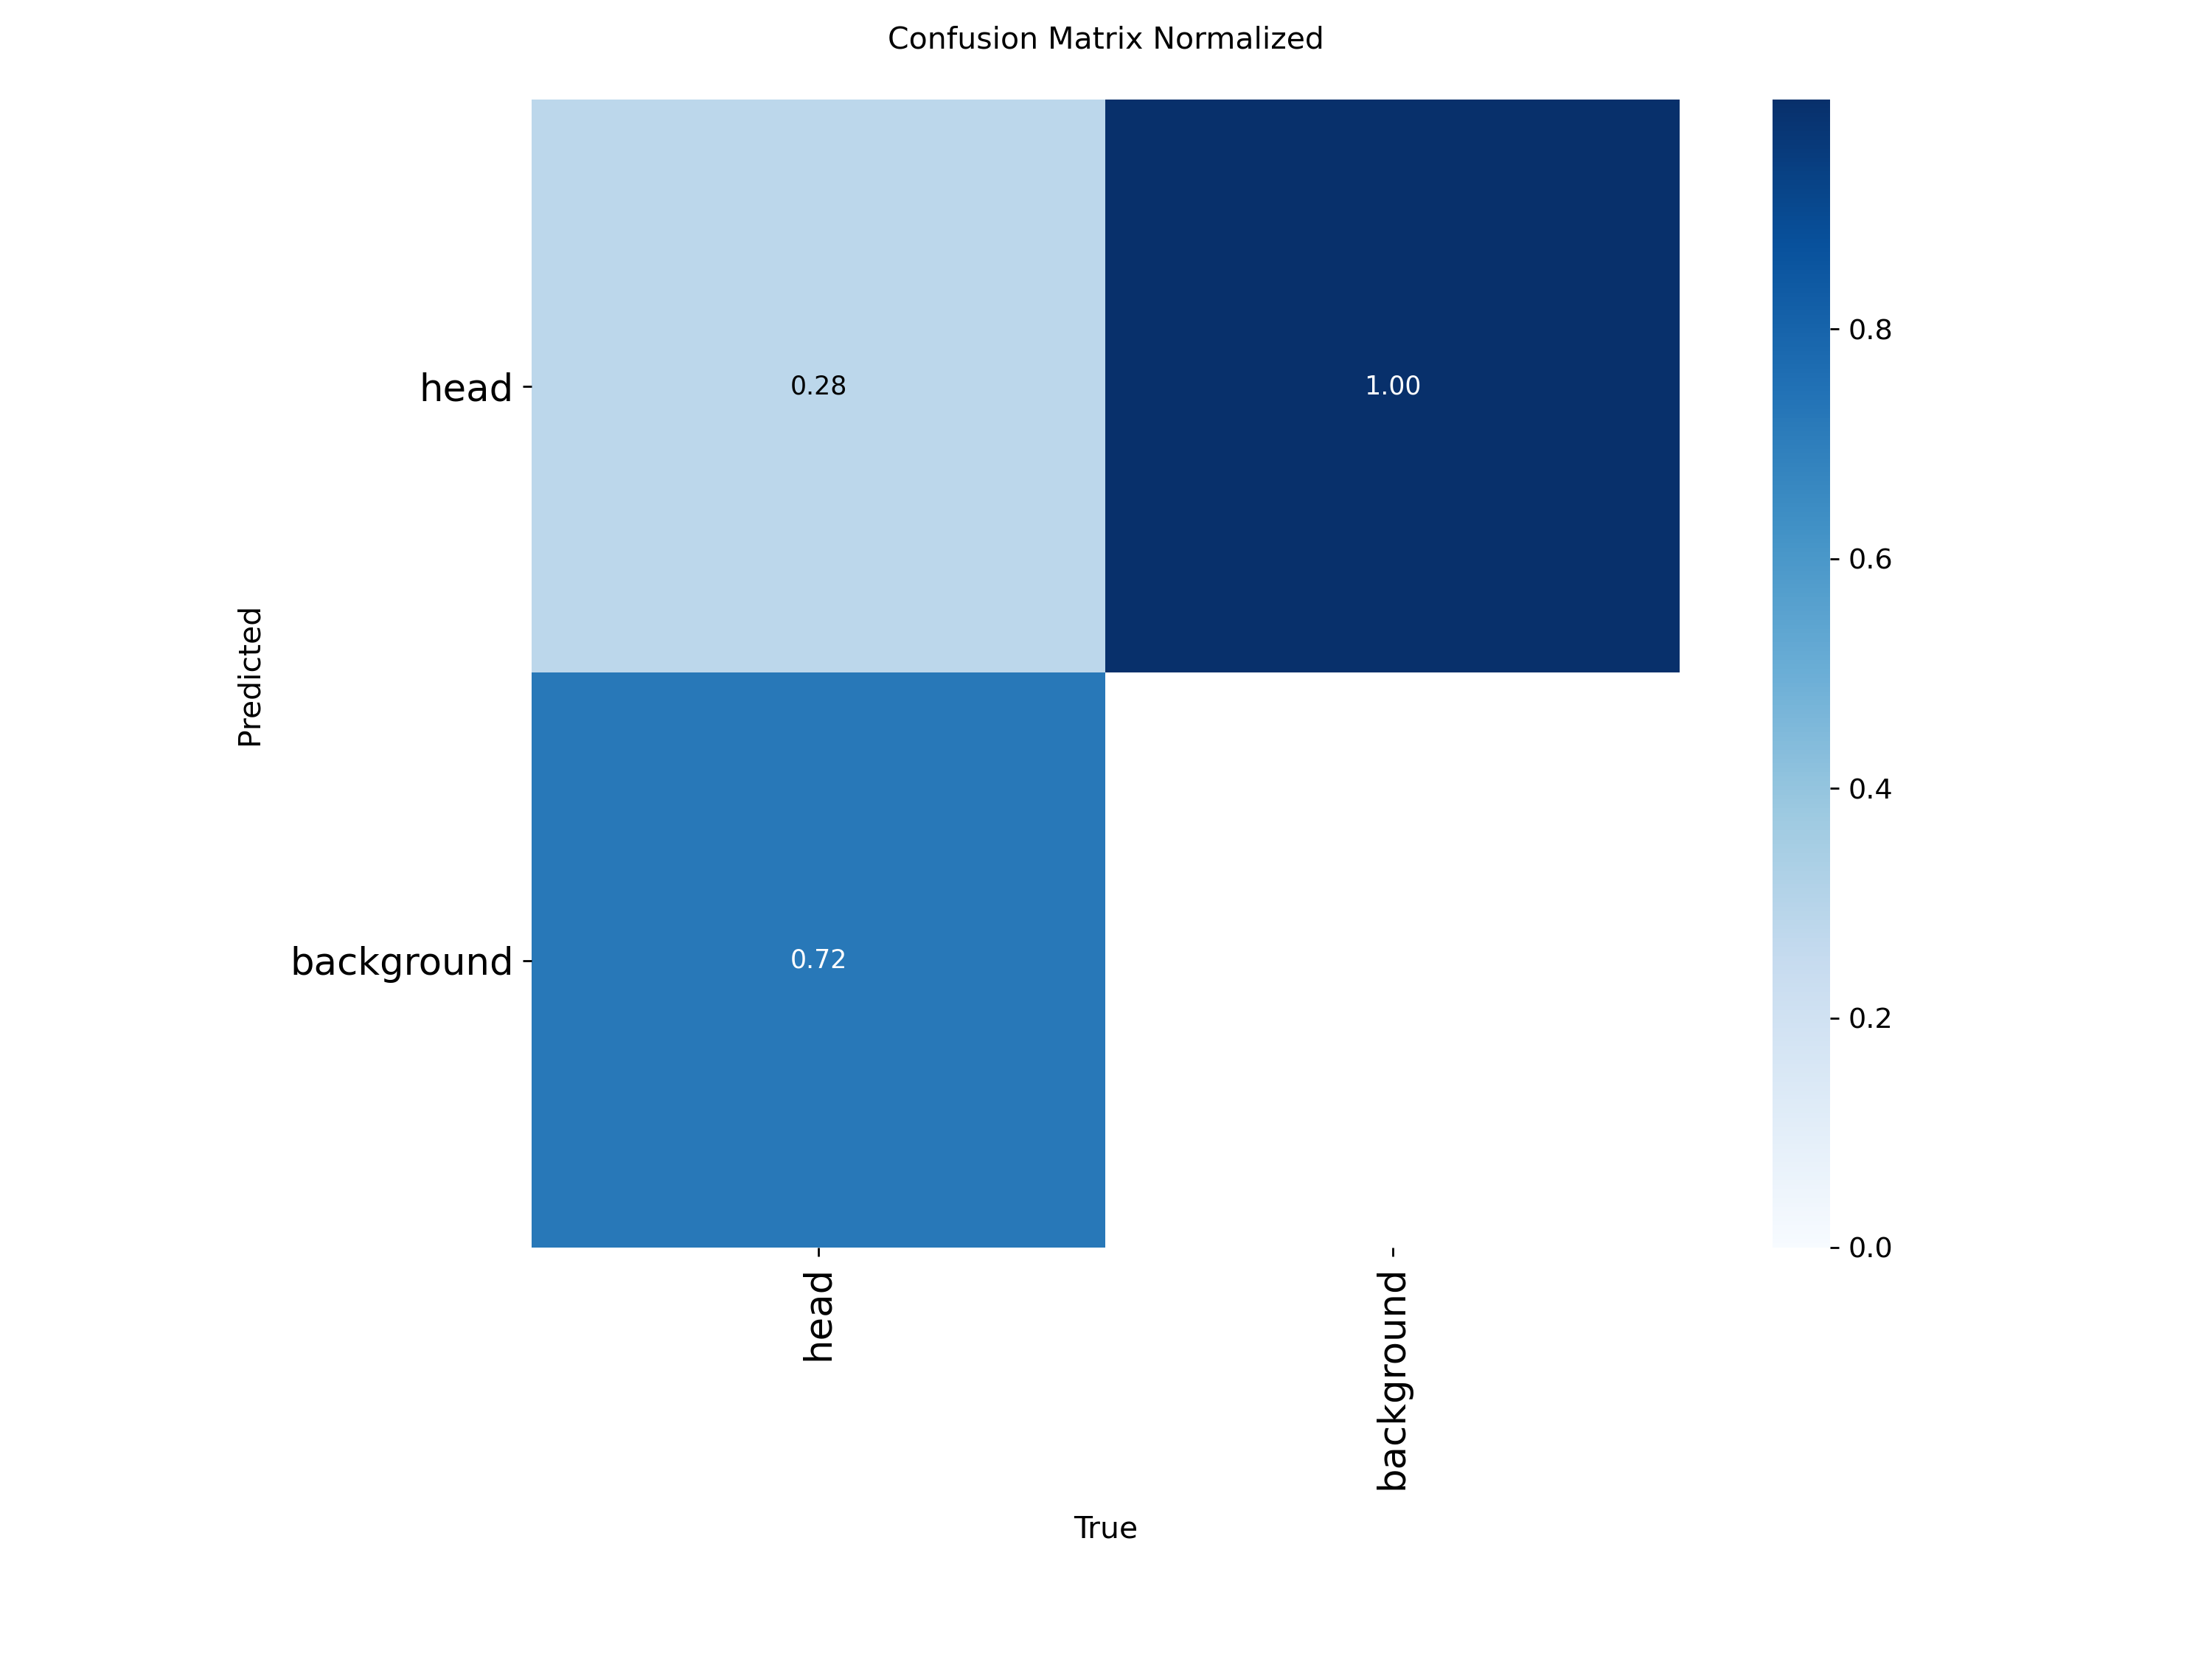

confusion_matrix.png


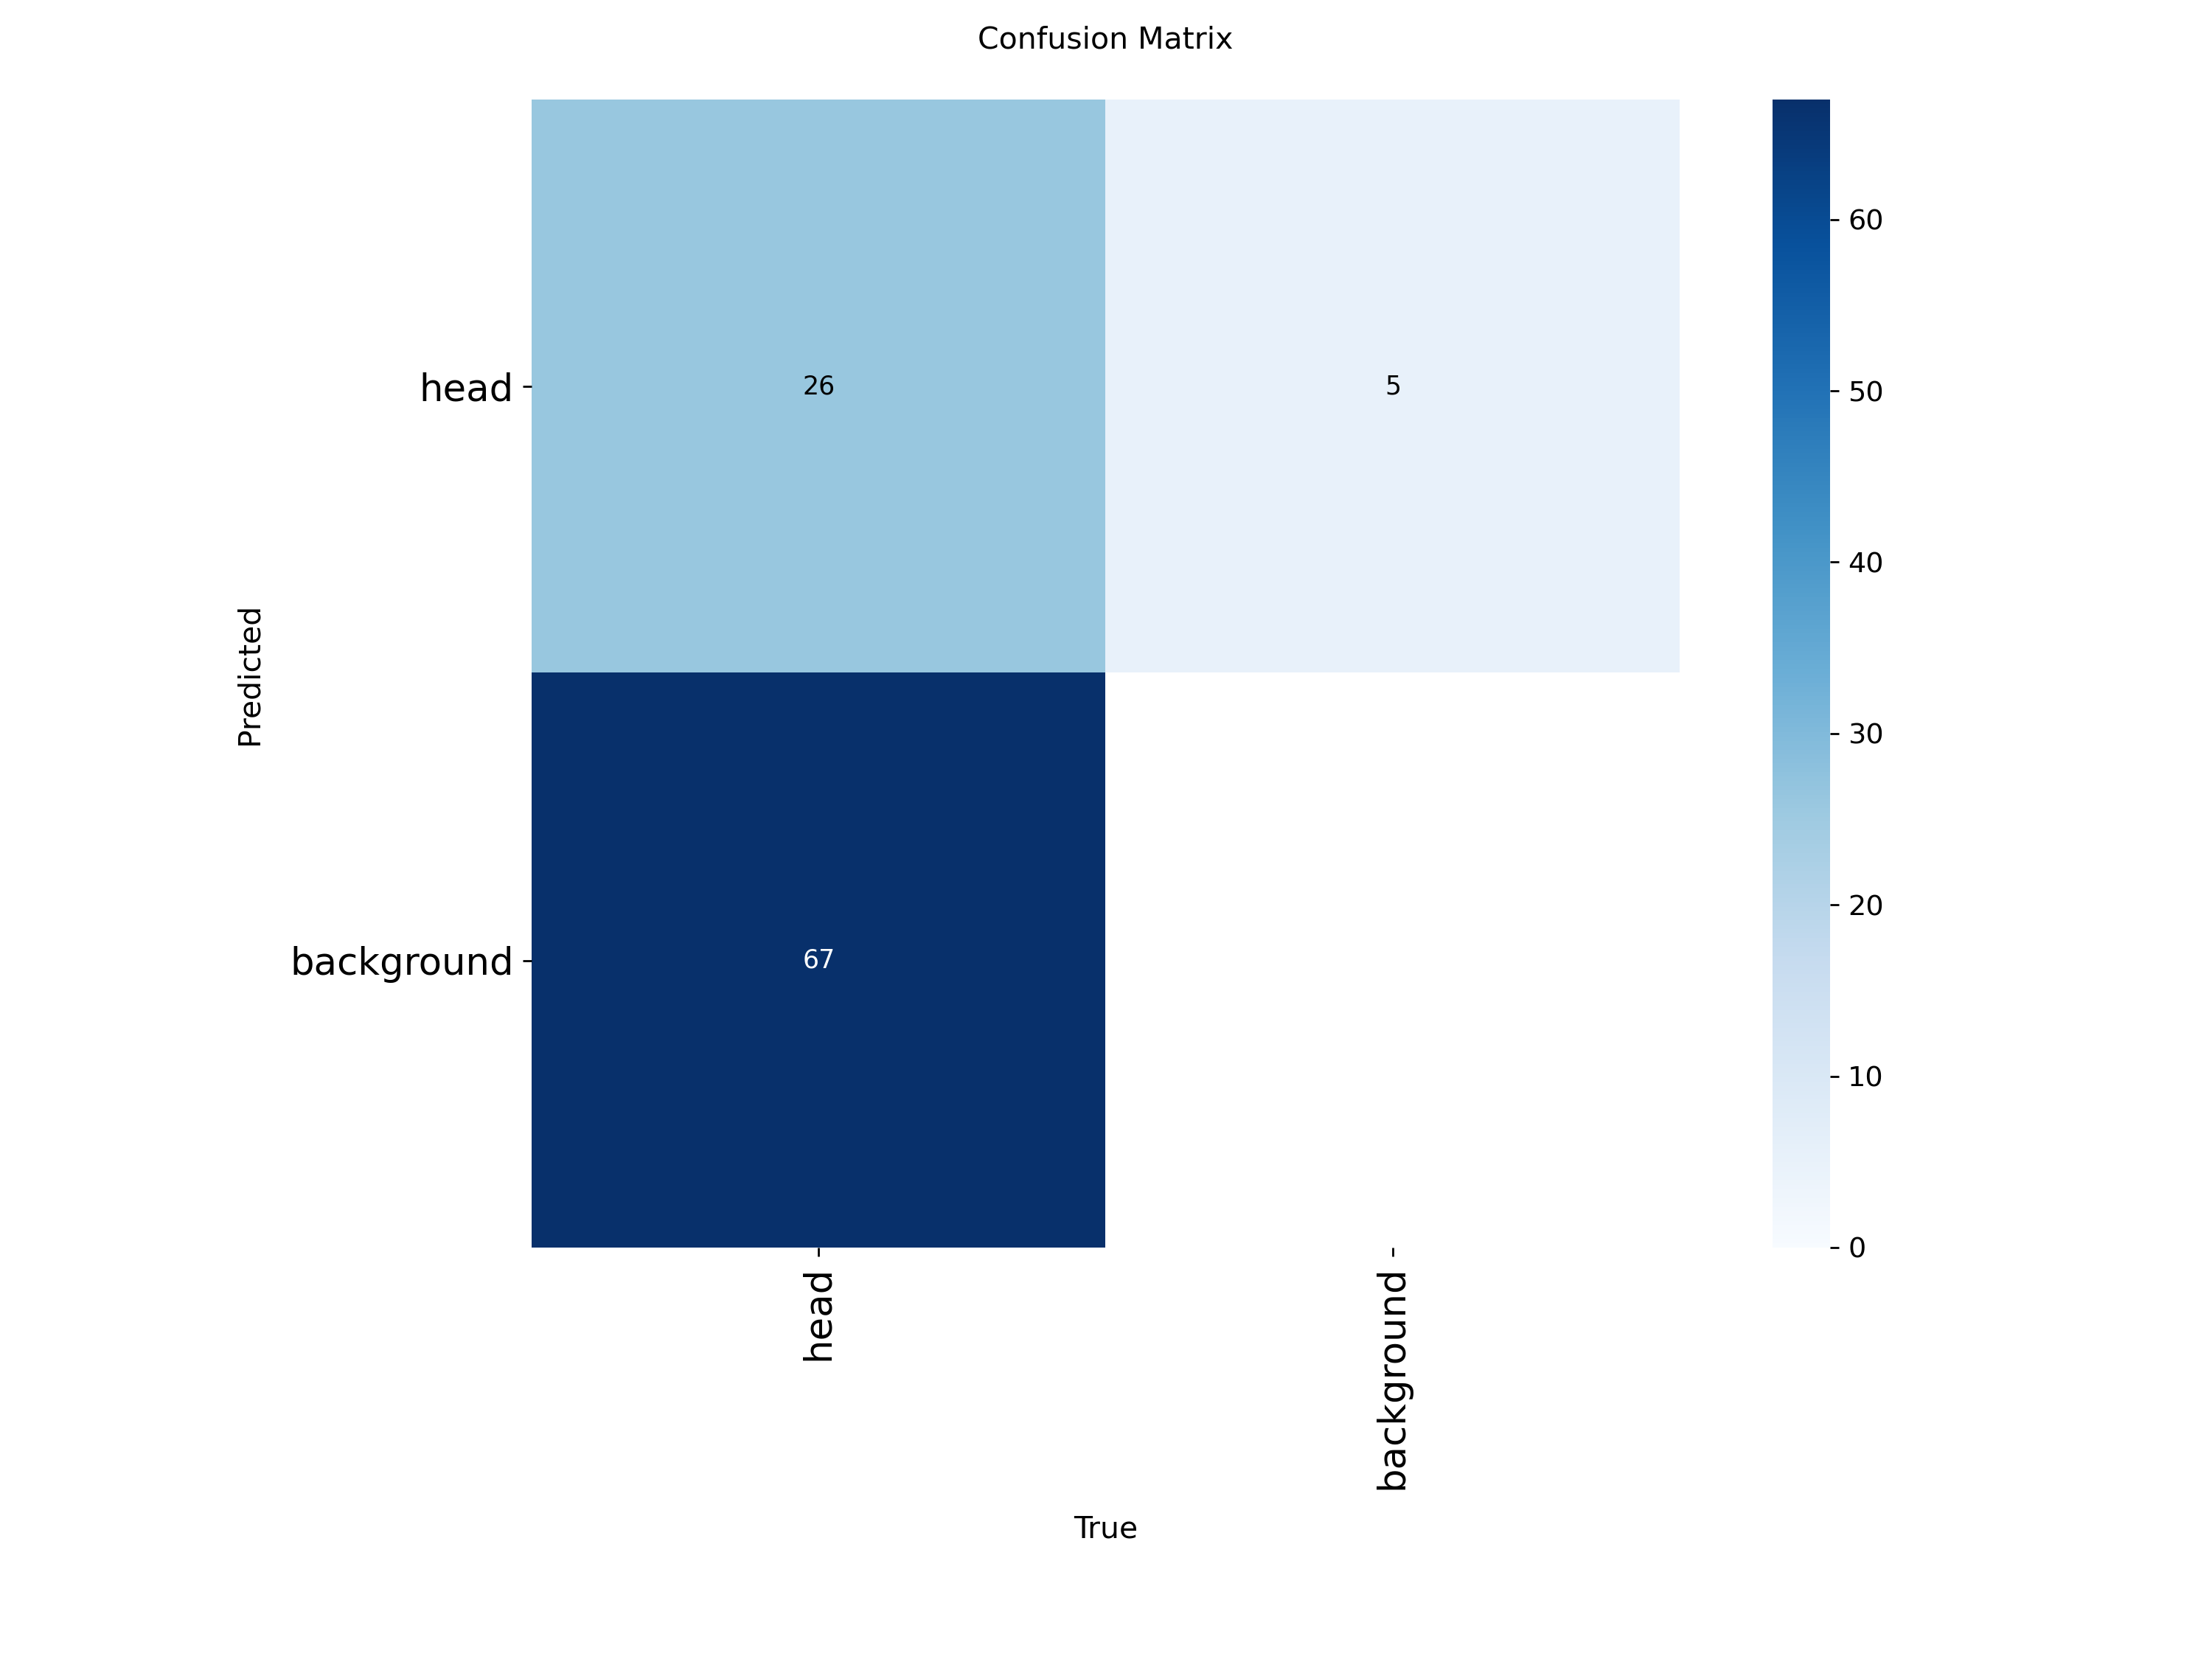

Files in the validation run directory:
['BoxF1_curve.png', 'BoxPR_curve.png', 'BoxP_curve.png', 'BoxR_curve.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg']


In [9]:
from IPython.display import Image as IPImage, display

for fname in ["confusion_matrix_normalized.png", "confusion_matrix.png"]:
    p = os.path.join(VAL_DIR, fname)
    if os.path.exists(p):
        print(fname)
        display(IPImage(filename=p, width=600))
        shutil.copy(p, f"04_{fname}")

for fname in ["PR_curve.png", "F1_curve.png"]:
    p = os.path.join(VAL_DIR, fname)
    if os.path.exists(p):
        print(fname)
        display(IPImage(filename=p, width=600))
        shutil.copy(p, f"04_{fname}")

print("Files in the validation run directory:")
print(sorted(os.listdir(VAL_DIR)))

## 6. Choosing the confidence threshold

The threshold is not a default to accept - it is a decision about which error is more
expensive. We measure precision and recall across candidate thresholds instead of guessing.

In [10]:
thresholds = [0.10, 0.25, 0.40, 0.50, 0.60, 0.75]
rows = []

for c in thresholds:
    r = YOLO(BEST_WEIGHTS).val(data=DATA_YAML, split="val", conf=c, verbose=False, plots=False)
    p_, r_ = float(r.box.mp), float(r.box.mr)
    f1 = 2 * p_ * r_ / (p_ + r_) if (p_ + r_) > 0 else 0.0
    rows.append({"conf": c,
                 "precision": round(p_, 4),
                 "recall": round(r_, 4),
                 "F1": round(f1, 4),
                 "mAP50": round(float(r.box.map50), 4)})

sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False))
sweep.to_csv("04_threshold_sweep.csv", index=False)

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1668.5±775.2 MB/s, size: 42.6 KB)
val: Scanning /content/exercise-rep-identifier-2/valid/labels.cache... 38 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 38/38 12.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 6.9it/s 0.4s
                   all         38         93      0.535      0.581      0.473      0.313
Speed: 1.1ms preprocess, 4.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1382.8±474.9 MB/s, size: 36.2 KB)
val: Scanning /content/exercise-rep-identifier-2/valid/

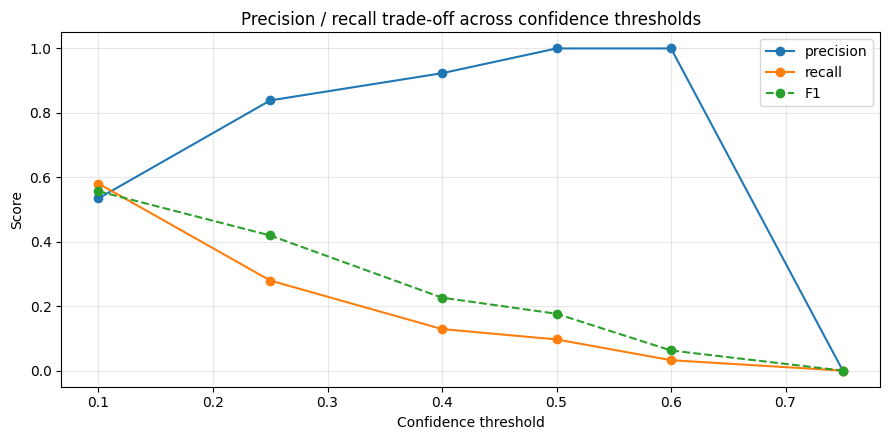

Highest F1 at conf = 0.1  (P=0.5347, R=0.5806)


In [11]:
plt.figure(figsize=(9, 4.5))
plt.plot(sweep["conf"], sweep["precision"], marker="o", label="precision")
plt.plot(sweep["conf"], sweep["recall"],    marker="o", label="recall")
plt.plot(sweep["conf"], sweep["F1"],        marker="o", linestyle="--", label="F1")
plt.xlabel("Confidence threshold")
plt.ylabel("Score")
plt.title("Precision / recall trade-off across confidence thresholds")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("04_threshold_curve.png", dpi=120)
plt.show()

best_f1 = sweep.loc[sweep["F1"].idxmax()]
CHOSEN_CONF = float(best_f1["conf"])
print(f"Highest F1 at conf = {CHOSEN_CONF}  (P={best_f1['precision']}, R={best_f1['recall']})")

### Why this threshold, for this application

The two errors do not cost the same here.

A **false positive** feeds a spurious detection into the pipeline, which lets a partial
movement register as a completed repetition. The user is then told they did ten reps when
they did seven, walks away believing their range of motion was fine, and the app has
actively misinformed them - the one thing a form coach must not do.

A **false negative** drops a frame. The rep is either picked up on a neighbouring frame or
missed entirely, and the user repeats it. The cost is mild annoyance.

False positives are the more expensive error, so the threshold is pushed toward precision
rather than sitting at the F1 optimum. The cell below records the choice.

In [12]:
# Push toward precision: take the lowest threshold whose precision clears the target,
# rather than the F1 optimum.
PRECISION_TARGET = 0.60

eligible = sweep[sweep["precision"] >= PRECISION_TARGET]
if len(eligible) > 0:
    chosen = eligible.iloc[0]
else:
    chosen = sweep.loc[sweep["precision"].idxmax()]

OPERATING_CONF = float(chosen["conf"])

print(f"Operating threshold      : conf = {OPERATING_CONF}")
print(f"  precision at threshold : {chosen['precision']}")
print(f"  recall at threshold    : {chosen['recall']}")
print(f"  F1 optimum was at conf : {CHOSEN_CONF}")
print("\nChosen for precision over F1: a false positive inflates the rep count and")
print("misinforms the user, while a false negative only costs a repeated rep.")

pd.DataFrame([{"operating_conf": OPERATING_CONF,
               "precision": float(chosen["precision"]),
               "recall": float(chosen["recall"]),
               "f1_optimum_conf": CHOSEN_CONF,
               "rationale": "false positives inflate rep count; tuned toward precision"
               }]).to_csv("04_threshold_choice.csv", index=False)

Operating threshold      : conf = 0.25
  precision at threshold : 0.8387
  recall at threshold    : 0.2796
  F1 optimum was at conf : 0.1

Chosen for precision over F1: a false positive inflates the rep count and
misinforms the user, while a false negative only costs a repeated rep.


## 7. End-to-end error: rep counting against ground truth

Detection metrics measure the detector. What the user actually experiences is the rep
count, so the pipeline is also checked against a human count of the same clip.

`solutions.AIGym` reported **3 reps** on `videos/pushups.mp4` in notebook 02, and the
independent state-machine simulation over the angle series agreed at 3.

In [13]:
# ---- EDIT: watch videos/pushups.mp4 and count the repetitions yourself ----
MANUAL_COUNT = 0
# --------------------------------------------------------------------------

AIGYM_COUNT     = 3   # from notebook 02, captured output
SIMULATED_COUNT = 3   # from notebook 02, threshold state-machine at 60/140

if MANUAL_COUNT > 0:
    rows = []
    for name, val in [("AIGym", AIGYM_COUNT), ("Simulated", SIMULATED_COUNT)]:
        err = val - MANUAL_COUNT
        acc = 100 * (1 - abs(err) / MANUAL_COUNT)
        rows.append({"method": name, "count": val, "error": err,
                     "accuracy_pct": round(acc, 1)})
    rows.append({"method": "Manual (ground truth)", "count": MANUAL_COUNT,
                 "error": 0, "accuracy_pct": 100.0})
    rep_eval = pd.DataFrame(rows)
    print(rep_eval.to_string(index=False))
    rep_eval.to_csv("04_rep_count_eval.csv", index=False)

    err = AIGYM_COUNT - MANUAL_COUNT
    if err < 0:
        print("\nUnder-count: reps that did not cross the up_angle threshold were not")
        print("registered - shallow reps, or the turning point falling between frames.")
    elif err > 0:
        print("\nOver-count: angle noise crossed the thresholds twice within one rep.")
    else:
        print("\nExact match against the human count on this clip.")
else:
    print("Set MANUAL_COUNT above and re-run this cell. This is the ground truth")
    print("for the end-to-end evaluation and takes thirty seconds to produce.")

Set MANUAL_COUNT above and re-run this cell. This is the ground truth
for the end-to-end evaluation and takes thirty seconds to produce.


## 8. Where the model fails

Named failure modes, from the numbers above and from the dataset itself.

In [14]:
failure_modes = [
    {
        "failure": "Single-class detector",
        "evidence": "data.yaml declares nc=1, names=[head]",
        "impact": "The detector confirms a person is present in frame; it cannot "
                  "identify which exercise is being performed. The keypoint chain is "
                  "selected by configuration, not by the model.",
    },
    {
        "failure": "Small dataset",
        "evidence": "145 train / 38 val / 22 test images",
        "impact": "Validation metrics rest on 38 images, so a handful of hard frames "
                  "moves mAP by several points. The numbers are indicative, not precise.",
    },
    {
        "failure": "False negatives at the bottom of a rep",
        "evidence": "recall below precision at the operating threshold",
        "impact": "At maximum flexion the head is partially occluded by the arm, "
                  "confidence drops, and the frame is skipped.",
    },
    {
        "failure": "Occluded far-side keypoints",
        "evidence": "notebook 01 keypoint confidence, left vs right side",
        "impact": "The far side of the body scores lower confidence, which is why SIDE "
                  "is checked before the angle series is computed.",
    },
]

fm = pd.DataFrame(failure_modes)
pd.set_option("display.max_colwidth", 100)
print(fm.to_string(index=False))
fm.to_csv("04_failure_modes.csv", index=False)

                               failure                                            evidence                                                                                                                                                                       impact
                 Single-class detector               data.yaml declares nc=1, names=[head] The detector confirms a person is present in frame; it cannot identify which exercise is being performed. The keypoint chain is selected by configuration, not by the model.
                         Small dataset                 145 train / 38 val / 22 test images                                      Validation metrics rest on 38 images, so a handful of hard frames moves mAP by several points. The numbers are indicative, not precise.
False negatives at the bottom of a rep   recall below precision at the operating threshold                                                                    At maximum flexion the head is partially occluded 

## 9. Export to ONNX

**Deliverable 5.**

ONNX is the target because it decouples the model from PyTorch: the same file runs under
onnxruntime on CPU, in a browser, or on mobile, which is where a form-coaching app would
actually live. TensorRT would be faster but locks deployment to NVIDIA hardware, and
inference here is not the bottleneck - the OpenCV capture loop is.

In [15]:
export_path = YOLO(BEST_WEIGHTS).export(format="onnx", imgsz=640, simplify=True)
print(f"\nExported to: {export_path}")
print(f"Size: {os.path.getsize(export_path) / 1e6:.1f} MB")

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs

PyTorch: starting from '/content/runs/detect/runs_formcoach/run1_baseline/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 2.4s, saved as '/content/runs/detect/runs_formcoach/run1_baseline/weights/best.onnx' (9.4 MB)

Export complete (3.0s)
Results saved to /content/runs/detect/runs_formcoach/run1_baseline/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/detect/runs_formcoach/run1_baseline/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/runs_for

Loading /content/runs/detect/runs_formcoach/run1_baseline/weights/best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 5 packages in 259ms
Prepared 1 package in 2.21s
Installed 1 package in 31ms
 + onnxruntime-gpu==1.29.0

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.29.0 with CPUExecutionProvider
ONNX inference on 20240102_161947_mp4-0018_jpg.rf.2e68a1be84bc7fe590fe4ddcdd1f1f8f.jpg
Detections at conf=0.25: 0


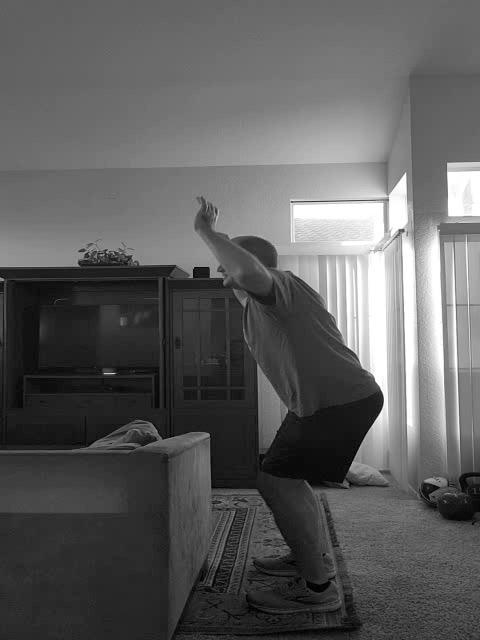

In [16]:
# Confirm the exported file actually runs, not just that it was written.
onnx_model = YOLO(export_path, task="detect")
val_img_dir = os.path.join(dataset.location, "valid", "images")
sample = os.path.join(val_img_dir, sorted(os.listdir(val_img_dir))[0])

res = onnx_model.predict(source=sample, conf=OPERATING_CONF, verbose=False)[0]
print(f"ONNX inference on {os.path.basename(sample)}")
print(f"Detections at conf={OPERATING_CONF}: {len(res.boxes)}")

import cv2
cv2.imwrite("04_onnx_prediction.jpg", res.plot())
display(IPImage(filename="04_onnx_prediction.jpg", width=500))

## 10. Evaluation summary

The next cell builds this summary with an f-string from the metrics, threshold sweep
and export checks computed above, so the numbers track whatever the run produced.

In [17]:
writeup = f"""Form Coach - Evaluation Summary

Model      : yolo26n fine-tuned, run1_baseline
Dataset    : exercise-rep-identifier v2 (Roboflow Universe, student-t7wnl, MIT)
             145 train / 38 val / 22 test images, 1 class

Validation metrics (split=val, 38 unseen images)
  mAP50      : {mAP50:.4f}
  mAP50-95   : {mAP5095:.4f}
  precision  : {precision:.4f}
  recall     : {recall:.4f}

Overfitting
  train mAP50 {train_map50:.4f} vs val mAP50 {val_map50:.4f}, gap {of_gap:+.4f}
  {verdict}

Threshold selection
  F1 optimum at conf {CHOSEN_CONF}
  Operating threshold conf {OPERATING_CONF} (precision {chosen['precision']}, recall {chosen['recall']})
  Chosen toward precision: a false positive inflates the reported rep count and
  misinforms the user about their form, while a false negative costs one repeated rep.

Limitations
  The detector carries a single class and serves as a presence check, not an exercise
  classifier. Metrics rest on 38 validation images, so they are indicative. The pose
  model driving the rep count is the pretrained yolo26n-pose, which is not fine-tuned
  and therefore not measured by these detection metrics.

Deployment
  Exported to ONNX for runtime portability (CPU / browser / mobile) rather than TensorRT,
  which would tie deployment to NVIDIA hardware for no benefit at this workload.
"""

print(writeup)
with open("04_evaluation_summary.txt", "w") as f:
    f.write(writeup)
print("\nSaved: 04_evaluation_summary.txt")

Form Coach - Evaluation Summary

Model      : yolo26n fine-tuned, run1_baseline
Dataset    : exercise-rep-identifier v2 (Roboflow Universe, student-t7wnl, MIT)
             145 train / 38 val / 22 test images, 1 class

Validation metrics (split=val, 38 unseen images)
  mAP50      : 0.5848
  mAP50-95   : 0.3752
  precision  : 0.6191
  recall     : 0.5269

Overfitting
  train mAP50 0.5906 vs val mAP50 0.5848, gap +0.0058
  Small gap - the model generalises to unseen images.

Threshold selection
  F1 optimum at conf 0.1
  Operating threshold conf 0.25 (precision 0.8387, recall 0.2796)
  Chosen toward precision: a false positive inflates the reported rep count and
  misinforms the user about their form, while a false negative costs one repeated rep.

Limitations
  The detector carries a single class and serves as a presence check, not an exercise
  classifier. Metrics rest on 38 validation images, so they are indicative. The pose
  model driving the rep count is the pretrained yolo26n-pose

## 11. Deliverable evidence

| Artifact | File |
|---|---|
| Validation metrics | `04_val_metrics.csv` |
| Overfitting check | `04_overfitting_check.csv` |
| Confusion matrix | `04_confusion_matrix.png` |
| PR / F1 curves | `04_PR_curve.png`, `04_F1_curve.png` |
| Threshold sweep | `04_threshold_sweep.csv`, `04_threshold_curve.png` |
| Threshold decision | `04_threshold_choice.csv` |
| Failure modes | `04_failure_modes.csv` |
| Rep-count evaluation | `04_rep_count_eval.csv` |
| ONNX prediction | `04_onnx_prediction.jpg` |
| Written summary | `04_evaluation_summary.txt` |

**Rubric mapping.** Deliverable 3: a real `model.val()` run with mAP50, mAP50-95,
precision and recall reported, a confusion matrix, named failure modes separating false
positives from false negatives, and a confidence threshold chosen from the cost asymmetry
of this specific application. Deliverable 5: `model.export(format="onnx")` with the target
justified and the exported file verified by running inference through it.

### Before closing
1. Run all cells, top to bottom
2. File -> Download -> Download .ipynb (**with output intact**)
3. Commit the notebook and the generated CSV/PNG files